## UK Online Retail Sales & Customer Behaviour Analysis

This project analyses 541,909 transaction-line records to understand sales performance, product demand, customer value, international markets and seasonal behaviour.


### Data Dictionary

| Column | Description |
|---|---|
| InvoiceNo | Unique invoice identifier; invoices beginning with `C` are cancellations |
| StockCode | Product identifier |
| Description | Product name |
| Quantity | Units recorded on the invoice line |
| InvoiceDate | Transaction date and time |
| UnitPrice | Price per unit in pounds sterling |
| CustomerID | Customer identifier |
| Country | Customer country |

###  Import Libraries

In [10]:
import warnings
import math
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Load the Dataset

In [11]:
df_raw = pd.read_excel(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_Online_Retail_Business_Sales_Analysis\Online Retail.xlsx')
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Data Quality Assessment

In [13]:
quality = pd.DataFrame({
    "Data type": df_raw.dtypes.astype(str),
    "Missing values": df_raw.isna().sum(),
    "Missing percentage": (df_raw.isna().mean() * 100).round(2),
    "Unique values": df_raw.nunique(dropna=False)
})
quality

,Data type,Missing values,Missing percentage,Unique values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4224
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[ns],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4373
Country,object,0,0.00,38


In [14]:
duplicates = df_raw.duplicated().sum()
cancelled = df_raw["InvoiceNo"].astype(str).str.startswith("C").sum()
negative_qty = (df_raw["Quantity"] < 0).sum()
zero_price = (df_raw["UnitPrice"] == 0).sum()
negative_price = (df_raw["UnitPrice"] < 0).sum()

pd.Series({
    "Exact duplicate rows": duplicates,
    "Cancelled invoice lines": cancelled,
    "Negative quantity lines": negative_qty,
    "Zero-price lines": zero_price,
    "Negative-price lines": negative_price
}, name="Count").to_frame()

,Count
Exact duplicate rows,5268
Cancelled invoice lines,9288
Negative quantity lines,10624
Zero-price lines,2515
Negative-price lines,2



- Missing `CustomerID` values prevent customer-level tracking but do not invalidate product or overall sales analysis.
- Missing product descriptions are uncommon relative to the dataset size.
- Cancelled invoices and negative quantities represent returns/cancellations and should not be mixed with completed sales.
- Exact duplicates can overstate quantity and revenue.
- Zero or negative prices are not valid for the completed-sales analysis.

### Cancellation and Return Overview Before Cleaning

In [17]:
return_summary = pd.Series({
    "Cancelled invoice lines": cancelled,
    "Negative quantity lines": negative_qty,
    "Absolute units in negative-quantity lines": abs(df_raw.loc[df_raw["Quantity"] < 0, "Quantity"].sum())
})
return_summary.to_frame("Value")

,Value
Cancelled invoice lines,0 False 1 False 2 Fals...
Negative quantity lines,10624
Absolute units in negative-quantity lines,484531


### Data Cleaning

The main analysis focuses on completed sales. Returns and cancellations are documented above but excluded from revenue calculations.

In [20]:
df = df_raw.copy()
log = []

def record(step, before, after):
    log.append([step, before, after, before-after])

before = len(df)
df = df.drop_duplicates().copy()
record("Remove exact duplicates", before, len(df))

before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()
record("Remove cancelled invoices", before, len(df))

before = len(df)
df = df[df["Quantity"] > 0].copy()
record("Keep positive quantities", before, len(df))

before = len(df)
df = df[df["UnitPrice"] > 0].copy()
record("Keep positive unit prices", before, len(df))

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

cleaning_log = pd.DataFrame(
    log, columns=["Step", "Rows before", "Rows after", "Rows removed"]
)
cleaning_log

,Step,Rows before,Rows after,Rows removed
0,Remove exact duplicates,541909,536641,5268
1,Remove cancelled invoices,536641,527390,9251
2,Keep positive quantities,527390,526054,1336
3,Keep positive unit prices,526054,524878,1176


In [21]:
print(f"Clean rows: {len(df):,}")
print(f"Percentage retained: {len(df)/len(df_raw):.2%}")
print(f"Remaining missing CustomerID values: {df['CustomerID'].isna().sum():,}")
print(f"Remaining missing Description values: {df['Description'].isna().sum():,}")

Clean rows: 524,878
Percentage retained: 96.86%
Remaining missing CustomerID values: 132,186
Remaining missing Description values: 0


### Feature Engineering

New variables are created for revenue, time-based analysis, market comparison and order-level analysis.

In [22]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["Month"] = df["InvoiceDate"].dt.month_name()
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["WeekdayNumber"] = df["InvoiceDate"].dt.dayofweek
df["DayType"] = np.where(df["WeekdayNumber"] < 5, "Weekday", "Weekend")
df["Hour"] = df["InvoiceDate"].dt.hour
df["Date"] = df["InvoiceDate"].dt.date
df["Market"] = np.where(df["Country"] == "United Kingdom", "United Kingdom", "Non-UK")

order_df = (
    df.groupby(["InvoiceNo", "InvoiceDate", "Country", "Market", "DayType"], as_index=False)
      .agg(
          OrderValue=("Revenue", "sum"),
          Units=("Quantity", "sum"),
          ProductLines=("StockCode", "count"),
          UniqueProducts=("StockCode", "nunique")
      )
)

customer_df = df.dropna(subset=["CustomerID"]).copy()
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth,Month,Weekday,WeekdayNumber,DayType,Hour,Date,Market
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30,2010-12,December,Wednesday,2,Weekday,8,2010-12-01,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12,December,Wednesday,2,Weekday,8,2010-12-01,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00,2010-12,December,Wednesday,2,Weekday,8,2010-12-01,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12,December,Wednesday,2,Weekday,8,2010-12-01,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12,December,Wednesday,2,Weekday,8,2010-12-01,United Kingdom


### Key Performance Indicators

In [23]:
kpis = pd.DataFrame({
    "KPI": [
        "Valid revenue",
        "Completed invoices",
        "Unique products",
        "Countries",
        "Identified customers",
        "Average order value",
        "Median order value",
        "Average units per order"
    ],
    "Value": [
        f"£{df['Revenue'].sum():,.2f}",
        f"{df['InvoiceNo'].nunique():,}",
        f"{df['StockCode'].nunique():,}",
        f"{df['Country'].nunique():,}",
        f"{customer_df['CustomerID'].nunique():,}",
        f"£{order_df['OrderValue'].mean():,.2f}",
        f"£{order_df['OrderValue'].median():,.2f}",
        f"{order_df['Units'].mean():,.2f}"
    ]
})
kpis

,KPI,Value
0,Valid revenue,"£10,642,110.80"
1,Completed invoices,"19,960"
2,Unique products,"3,922"
3,Countries,38
4,Identified customers,"4,338"
5,Average order value,£532.05
6,Median order value,£303.13
7,Average units per order,278.59


### Descriptive Statistics

In [24]:
display(df[["Quantity", "UnitPrice", "Revenue"]].describe().T)
display(order_df[["OrderValue", "Units", "ProductLines", "UniqueProducts"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Quantity,"524,878.00",10.62,156.28,1.00,1.00,4.00,11.00,"80,995.00"
UnitPrice,"524,878.00",3.92,36.09,0.00,1.25,2.08,4.13,"13,541.33"
Revenue,"524,878.00",20.28,271.69,0.00,3.90,9.92,17.70,"168,469.60"


,count,mean,std,min,25%,50%,75%,max
OrderValue,"20,002.00",532.05,"1,775.43",0.38,151.41,303.13,493.01,"168,469.60"
Units,"20,002.00",278.59,953.50,1.00,69.00,150.00,295.00,"80,995.00"
ProductLines,"20,002.00",26.24,47.20,1.00,6.00,15.00,29.00,"1,114.00"
UniqueProducts,"20,002.00",25.98,46.89,1.00,6.00,15.00,29.00,"1,110.00"


### EDA — Order Value Distribution

Order values are highly right-skewed because the business includes wholesale customers and unusually large orders.

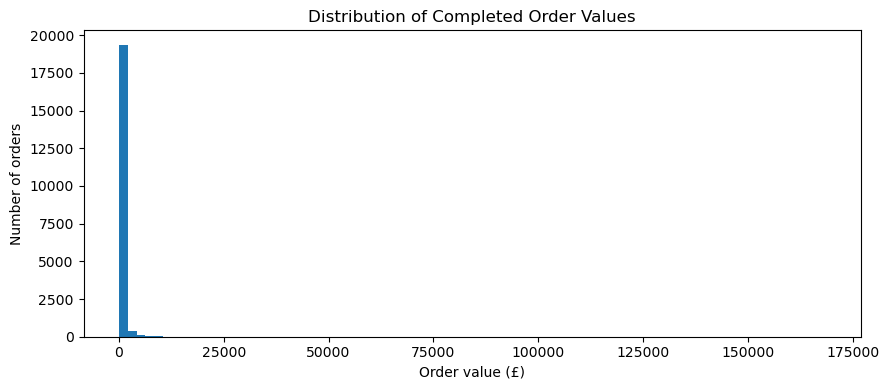

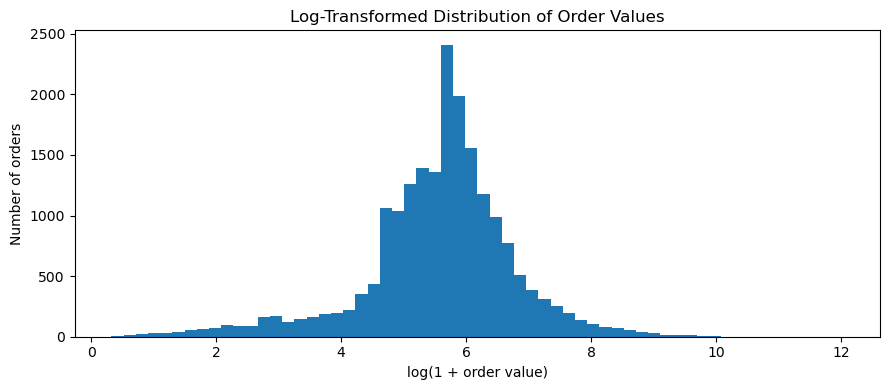

Order-value skewness: 51.35


In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(order_df["OrderValue"], bins=80)
ax.set_title("Distribution of Completed Order Values")
ax.set_xlabel("Order value (£)")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(order_df["OrderValue"]), bins=60)
ax.set_title("Log-Transformed Distribution of Order Values")
ax.set_xlabel("log(1 + order value)")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

print(f"Order-value skewness: {order_df['OrderValue'].skew():.2f}")

### Monthly Revenue Trend

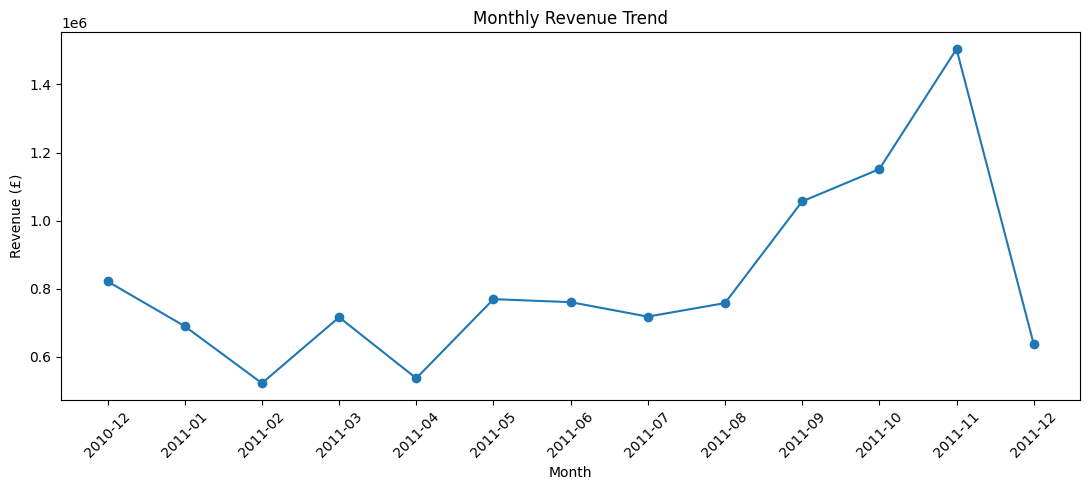

,YearMonth,Revenue,Orders,Month
0,2010-12,"821,452.73",1559,2010-12
1,2011-01,"689,811.61",1086,2011-01
2,2011-02,"522,545.56",1100,2011-02
3,2011-03,"716,215.26",1454,2011-03
4,2011-04,"536,968.49",1246,2011-04
5,2011-05,"769,296.61",1681,2011-05
6,2011-06,"760,547.01",1533,2011-06
7,2011-07,"718,076.12",1475,2011-07
8,2011-08,"757,841.38",1361,2011-08
9,2011-09,"1,056,435.19",1837,2011-09


In [13]:
monthly = (
    df.groupby("YearMonth", as_index=False)
      .agg(Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
      .sort_values("YearMonth")
)
monthly["Month"] = monthly["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Month"], monthly["Revenue"], marker="o")
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

monthly

In [14]:
full_months = monthly[monthly["Month"] != "2011-12"]
peak_month = full_months.loc[full_months["Revenue"].idxmax()]
low_month = full_months.loc[full_months["Revenue"].idxmin()]

print(f"Highest complete month: {peak_month['Month']} — £{peak_month['Revenue']:,.2f}")
print(f"Lowest complete month: {low_month['Month']} — £{low_month['Revenue']:,.2f}")
print("December 2011 is incomplete because the dataset ends on 9 December.")

Highest complete month: 2011-11 — £1,503,866.78
Lowest complete month: 2011-02 — £522,545.56
December 2011 is incomplete because the dataset ends on 9 December.


### Revenue and Orders by Weekday

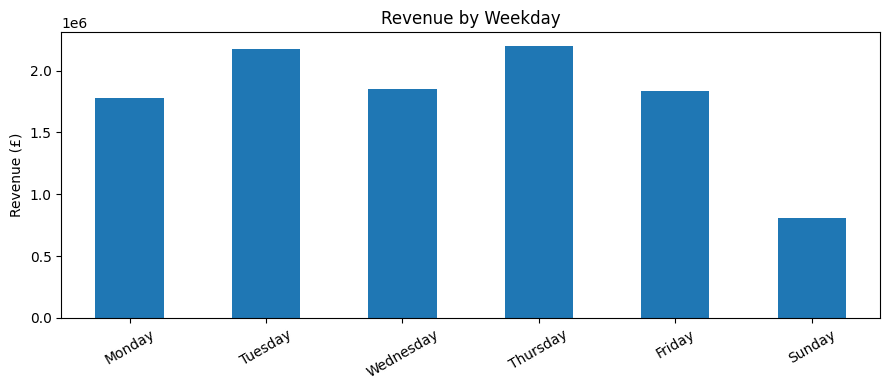

,Revenue,Orders
Weekday,,
Monday,"1,775,782.07","3,126.00"
Tuesday,"2,175,700.51","3,554.00"
Wednesday,"1,847,074.38","3,690.00"
Thursday,"2,199,292.57","4,246.00"
Friday,"1,837,470.49","3,140.00"
Sunday,"806,790.78","2,204.00"


In [15]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday = (
    df.groupby("Weekday")
      .agg(Revenue=("Revenue","sum"), Orders=("InvoiceNo","nunique"))
      .reindex(weekday_order)
      .dropna()
)

fig, ax = plt.subplots(figsize=(9, 4))
weekday["Revenue"].plot(kind="bar", ax=ax)
ax.set_title("Revenue by Weekday")
ax.set_xlabel("")
ax.set_ylabel("Revenue (£)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

weekday

### Revenue by Hour

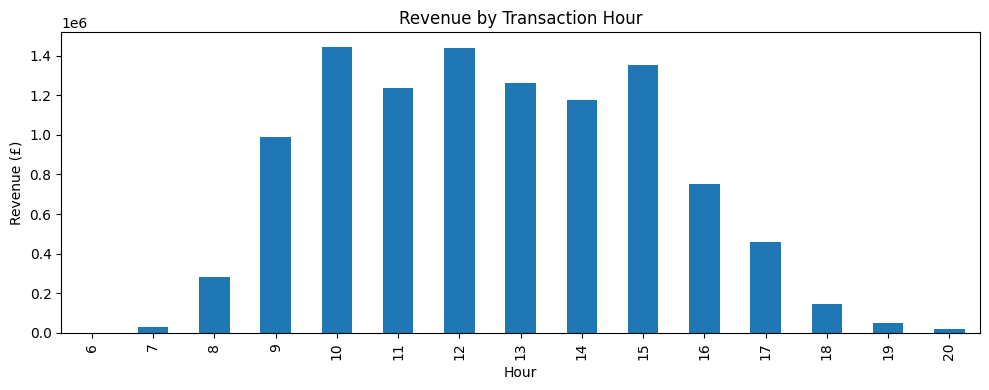

Peak revenue hour: 10:00


In [16]:
hourly = df.groupby("Hour").agg(
    Revenue=("Revenue","sum"),
    Orders=("InvoiceNo","nunique")
)

fig, ax = plt.subplots(figsize=(10, 4))
hourly["Revenue"].plot(kind="bar", ax=ax)
ax.set_title("Revenue by Transaction Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

print(f"Peak revenue hour: {hourly['Revenue'].idxmax()}:00")

### Country Performance

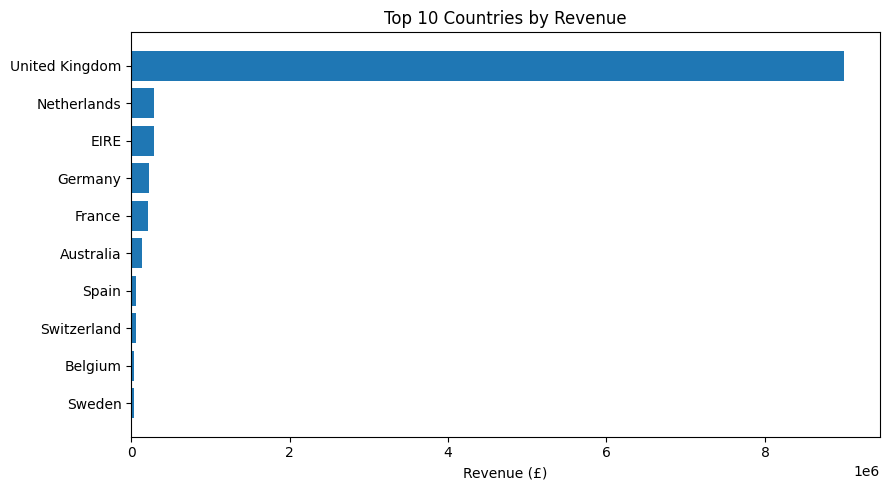

,Country,Revenue,Orders,Units
36,United Kingdom,"9,001,744.09",18019,4646906
24,Netherlands,"285,446.34",94,200361
10,EIRE,"283,140.52",288,147007
14,Germany,"228,678.40",457,119154
13,France,"209,625.37",392,112060
0,Australia,"138,453.81",57,83891
31,Spain,"61,558.56",90,27933
33,Switzerland,"57,067.60",54,30617
3,Belgium,"41,196.34",98,23237
32,Sweden,"38,367.83",36,36078


In [17]:
countries = (
    df.groupby("Country", as_index=False)
      .agg(
          Revenue=("Revenue","sum"),
          Orders=("InvoiceNo","nunique"),
          Units=("Quantity","sum")
      )
      .sort_values("Revenue", ascending=False)
)

top10 = countries.head(10).sort_values("Revenue")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["Country"], top10["Revenue"])
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

countries.head(10)

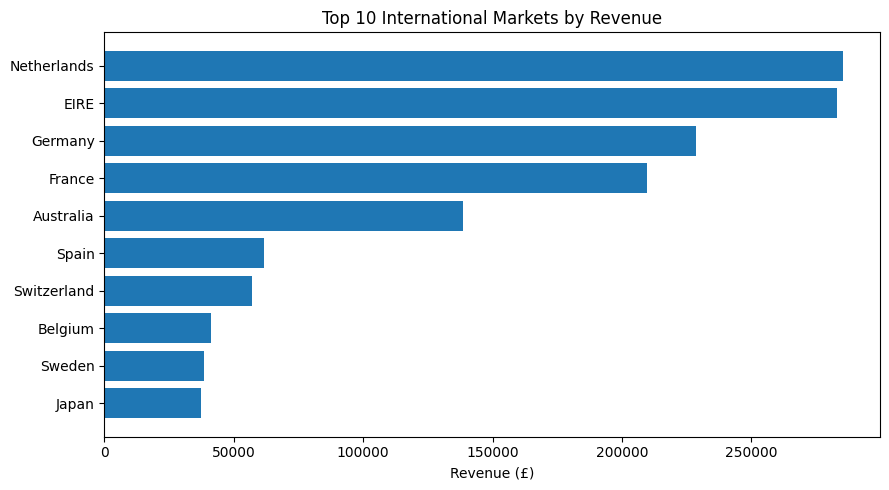

UK share of valid revenue: 84.6%


,Country,Revenue,Orders,Units
24,Netherlands,"285,446.34",94,200361
10,EIRE,"283,140.52",288,147007
14,Germany,"228,678.40",457,119154
13,France,"209,625.37",392,112060
0,Australia,"138,453.81",57,83891
31,Spain,"61,558.56",90,27933
33,Switzerland,"57,067.60",54,30617
3,Belgium,"41,196.34",98,23237
32,Sweden,"38,367.83",36,36078
20,Japan,"37,416.37",19,26016


In [18]:
international = countries[countries["Country"] != "United Kingdom"]
top_int = international.head(10).sort_values("Revenue")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_int["Country"], top_int["Revenue"])
ax.set_title("Top 10 International Markets by Revenue")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

uk_share = df.loc[df["Country"]=="United Kingdom","Revenue"].sum() / df["Revenue"].sum()
print(f"UK share of valid revenue: {uk_share:.1%}")
international.head(10)

### Product Performance

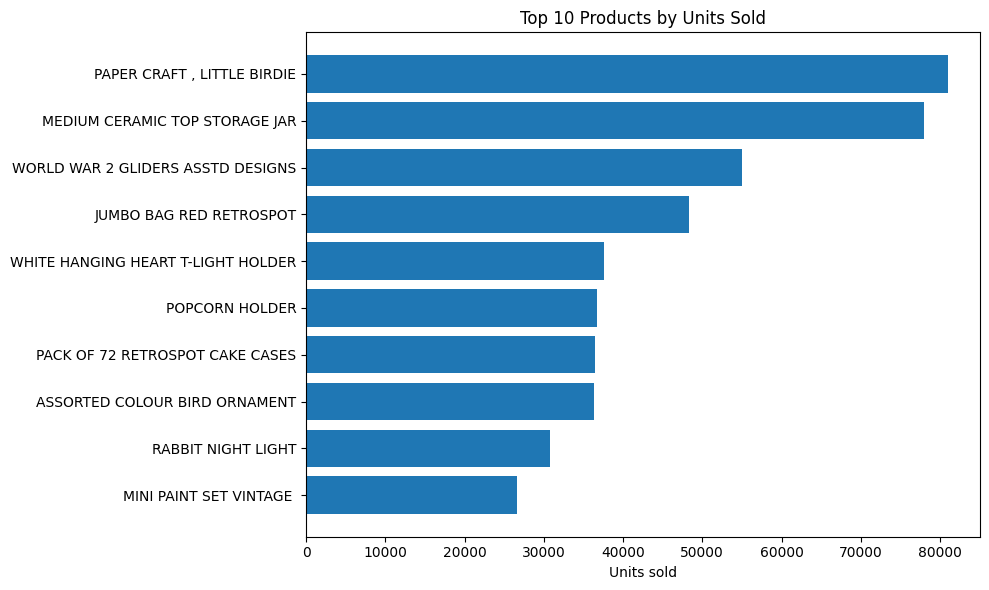

,StockCode,Description,UnitsSold,Revenue,Orders
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,"13,814.01",535
3761,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.81",2089
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.24",2189
1051,22197,POPCORN HOLDER,36749,"34,288.67",803
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.45",1320
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.62",1455
1951,23084,RABBIT NIGHT LIGHT,30739,"66,870.03",994
1327,22492,MINI PAINT SET VINTAGE,26633,"16,937.82",380


In [19]:
products = (
    df.dropna(subset=["Description"])
      .groupby(["StockCode","Description"], as_index=False)
      .agg(
          UnitsSold=("Quantity","sum"),
          Revenue=("Revenue","sum"),
          Orders=("InvoiceNo","nunique")
      )
)

top_units = products.nlargest(10, "UnitsSold").sort_values("UnitsSold")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_units["Description"], top_units["UnitsSold"])
ax.set_title("Top 10 Products by Units Sold")
ax.set_xlabel("Units sold")
plt.tight_layout()
plt.show()

products.nlargest(10, "UnitsSold")

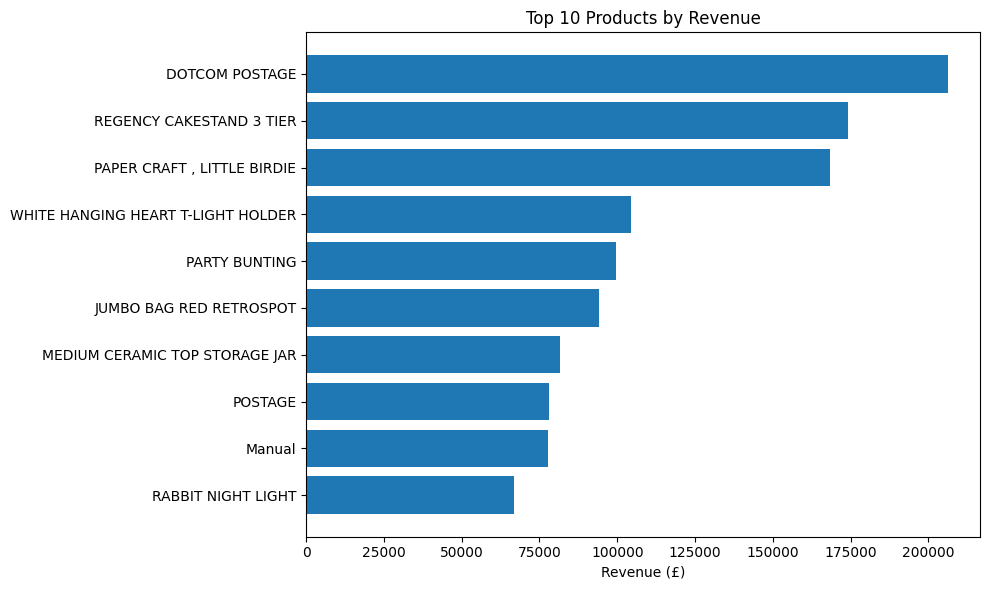

,StockCode,Description,UnitsSold,Revenue,Orders
4150,DOT,DOTCOM POSTAGE,706,"206,248.77",706
1262,22423,REGENCY CAKESTAND 3 TIER,13851,"174,156.54",1988
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.24",2189
2669,47566,PARTY BUNTING,18283,"99,445.23",1685
3761,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.81",2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247
4153,POST,POSTAGE,3150,"78,101.88",1126
4151,M,Manual,6984,"77,750.27",289
1951,23084,RABBIT NIGHT LIGHT,30739,"66,870.03",994


In [20]:
top_revenue = products.nlargest(10, "Revenue").sort_values("Revenue")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_revenue["Description"], top_revenue["Revenue"])
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

products.nlargest(10, "Revenue")

###  EDA — Customer Value

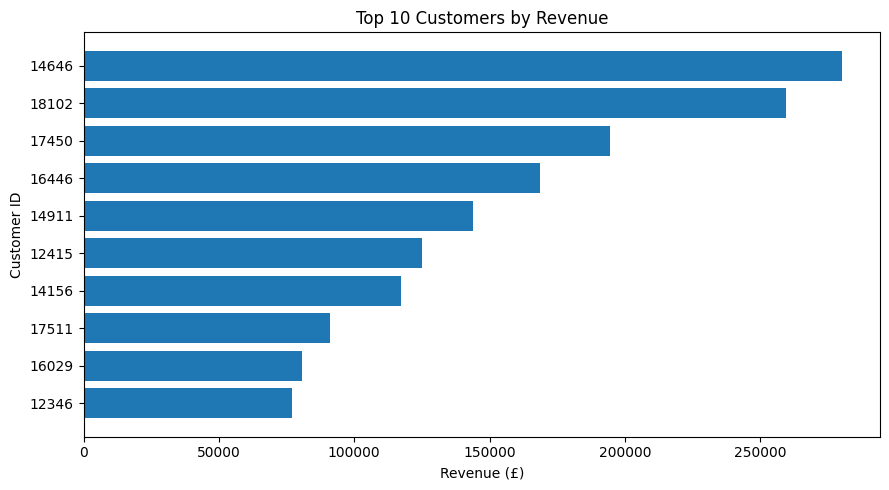

,CustomerID,Revenue,Orders,Units,FirstPurchase,LastPurchase,AverageOrderValue,ActiveDays
1689,14646,"280,206.02",73,196915,2010-12-20 10:09:00,2011-12-08 12:12:00,"3,838.44",353
4201,18102,"259,657.30",60,64124,2010-12-07 16:42:00,2011-12-09 11:50:00,"4,327.62",366
3728,17450,"194,390.79",46,69973,2010-12-07 09:23:00,2011-12-01 13:29:00,"4,225.89",359
3008,16446,"168,472.50",2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,"84,236.25",204
1879,14911,"143,711.17",201,80240,2010-12-01 14:05:00,2011-12-08 15:54:00,714.98,372
55,12415,"124,914.53",21,77374,2011-01-06 11:12:00,2011-11-15 14:22:00,"5,948.31",313
1333,14156,"117,210.08",55,57768,2010-12-03 11:48:00,2011-11-30 10:54:00,"2,131.09",361
3771,17511,"91,062.38",31,64549,2010-12-01 10:19:00,2011-12-07 10:12:00,"2,937.50",370
2702,16029,"80,850.84",63,40108,2010-12-01 09:57:00,2011-11-01 10:27:00,"1,283.35",335
0,12346,"77,183.60",1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,"77,183.60",0


In [21]:
customers = (
    customer_df.groupby("CustomerID", as_index=False)
      .agg(
          Revenue=("Revenue","sum"),
          Orders=("InvoiceNo","nunique"),
          Units=("Quantity","sum"),
          FirstPurchase=("InvoiceDate","min"),
          LastPurchase=("InvoiceDate","max")
      )
)
customers["AverageOrderValue"] = customers["Revenue"] / customers["Orders"]
customers["ActiveDays"] = (customers["LastPurchase"] - customers["FirstPurchase"]).dt.days

top_customers = customers.nlargest(10, "Revenue").sort_values("Revenue")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_customers["CustomerID"].astype(str), top_customers["Revenue"])
ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.show()

customers.nlargest(10, "Revenue")

###  Customer Revenue Concentration

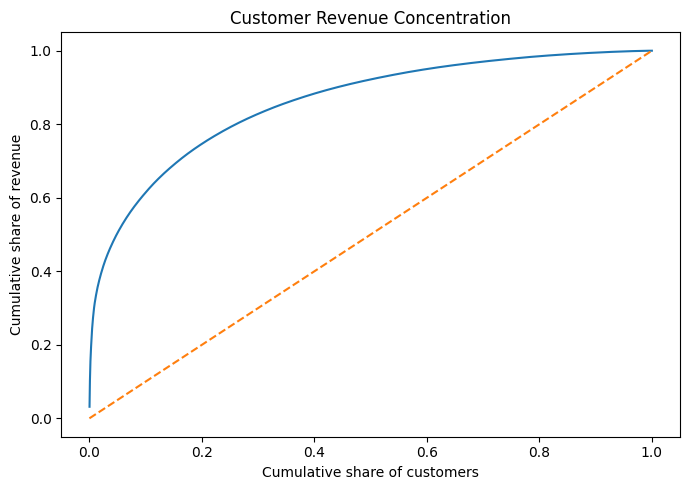

Top 10% of identified customers generate 61.5% of identified-customer revenue.


In [22]:
ranked = customers.sort_values("Revenue", ascending=False).reset_index(drop=True)
ranked["CumulativeRevenueShare"] = ranked["Revenue"].cumsum() / ranked["Revenue"].sum()
ranked["CumulativeCustomerShare"] = (np.arange(len(ranked)) + 1) / len(ranked)

n_top10 = math.ceil(len(ranked) * 0.10)
top10_share = ranked.head(n_top10)["Revenue"].sum() / ranked["Revenue"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ranked["CumulativeCustomerShare"], ranked["CumulativeRevenueShare"])
ax.plot([0,1],[0,1], linestyle="--")
ax.set_title("Customer Revenue Concentration")
ax.set_xlabel("Cumulative share of customers")
ax.set_ylabel("Cumulative share of revenue")
plt.tight_layout()
plt.show()

print(f"Top 10% of identified customers generate {top10_share:.1%} of identified-customer revenue.")

### Order-Level Correlation

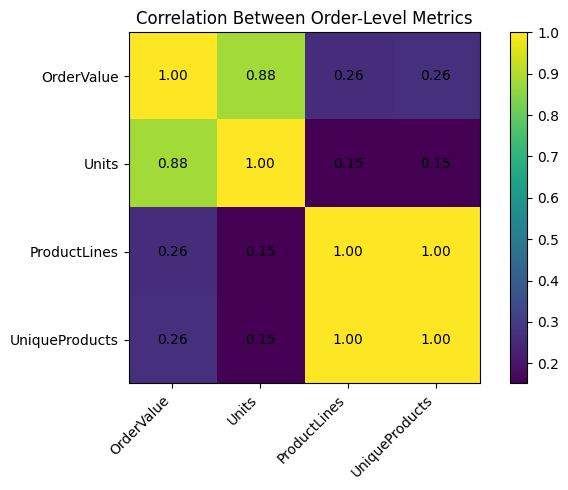

,OrderValue,Units,ProductLines,UniqueProducts
OrderValue,1.00,0.88,0.26,0.26
Units,0.88,1.00,0.15,0.15
ProductLines,0.26,0.15,1.00,1.00
UniqueProducts,0.26,0.15,1.00,1.00


In [23]:
corr = order_df[["OrderValue","Units","ProductLines","UniqueProducts"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Between Order-Level Metrics")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

corr

### Customer Segmentation with RFM

RFM groups customers using:

- **Recency:** how recently the customer purchased;
- **Frequency:** number of completed orders;
- **Monetary:** total revenue.

This is descriptive segmentation, not machine learning.

In [26]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    customer_df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
          Frequency=("InvoiceNo","nunique"),
          Monetary=("Revenue","sum")
      )
      .reset_index()
)

rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_Total"] = rfm[["R_Score","F_Score","M_Score"]].sum(axis=1)

rfm["Segment"] = pd.cut(
    rfm["RFM_Total"],
    bins=[2,5,8,10,12],
    labels=["At Risk / Low Value","Potential","Loyal","Champions"]
)

segment_summary = (
    rfm.groupby("Segment", observed=False)
       .agg(
           Customers=("CustomerID","count"),
           AverageRecency=("Recency","mean"),
           AverageFrequency=("Frequency","mean"),
           AverageMonetary=("Monetary","mean")
       )
)

segment_summary

,Customers,AverageRecency,AverageFrequency,AverageMonetary
Segment,,,,
At Risk / Low Value,1291,193.84,1.15,277.18
Potential,1370,79.16,2.17,833.94
Loyal,801,38.71,4.36,"1,868.66"
Champions,876,13.38,12.08,"6,723.83"


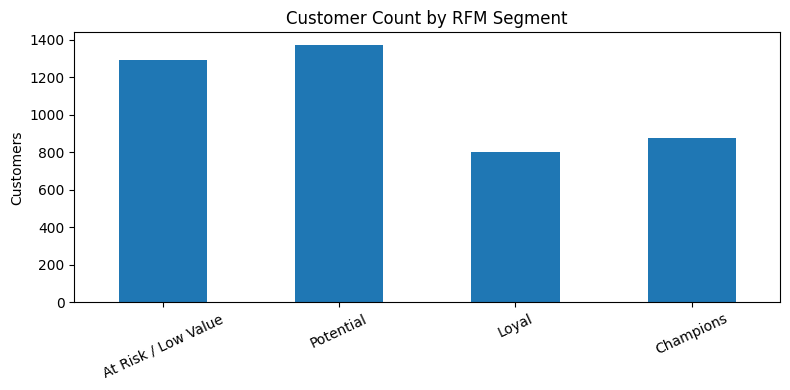

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
segment_summary["Customers"].plot(kind="bar", ax=ax)
ax.set_title("Customer Count by RFM Segment")
ax.set_xlabel("")
ax.set_ylabel("Customers")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Hypothesis Test 1 — UK vs Non-UK Order Value

**H₀:** Mean UK order value equals mean non-UK order value.  
**H₁:** The means are different.

Welch's t-test is used because equal variances are not assumed. The Mann–Whitney U test is included as a robustness check because order values are skewed.

In [27]:
uk = order_df.loc[order_df["Market"]=="United Kingdom","OrderValue"]
nonuk = order_df.loc[order_df["Market"]=="Non-UK","OrderValue"]

t1 = stats.ttest_ind(uk, nonuk, equal_var=False)
u1 = stats.mannwhitneyu(uk, nonuk, alternative="two-sided")

result1 = pd.DataFrame({
    "Group":["United Kingdom","Non-UK"],
    "Orders":[len(uk),len(nonuk)],
    "Mean":[uk.mean(),nonuk.mean()],
    "Median":[uk.median(),nonuk.median()]
})
display(result1)

print(f"Welch p-value: {t1.pvalue:.6g}")
print(f"Mann–Whitney p-value: {u1.pvalue:.6g}")
print("Decision:", "Reject H0" if t1.pvalue < 0.05 else "Fail to reject H0")

,Group,Orders,Mean,Median
0,United Kingdom,18058,498.49,299.47
1,Non-UK,1944,843.81,423.89


Welch p-value: 1.66838e-16
Mann–Whitney p-value: 1.89689e-83
Decision: Reject H0


### Hypothesis Test 2 — Weekday vs Weekend Order Value

**H₀:** Mean weekday and weekend order values are equal.  
**H₁:** The means are different.

The weekend group is limited because the dataset contains no Saturday transactions.

In [27]:
wd = order_df.loc[order_df["DayType"]=="Weekday","OrderValue"]
we = order_df.loc[order_df["DayType"]=="Weekend","OrderValue"]

t2 = stats.ttest_ind(wd, we, equal_var=False)
u2 = stats.mannwhitneyu(wd, we, alternative="two-sided")

result2 = pd.DataFrame({
    "Group":["Weekday","Weekend"],
    "Orders":[len(wd),len(we)],
    "Mean":[wd.mean(),we.mean()],
    "Median":[wd.median(),we.median()]
})
display(result2)

print(f"Welch p-value: {t2.pvalue:.6g}")
print(f"Mann–Whitney p-value: {u2.pvalue:.6g}")
print("Decision:", "Reject H0" if t2.pvalue < 0.05 else "Fail to reject H0")

,Group,Orders,Mean,Median
0,Weekday,17790,552.86,305.37
1,Weekend,2212,364.73,262.34


Welch p-value: 3.35158e-25
Mann–Whitney p-value: 1.26194e-09
Decision: Reject H0


### Key Findings

In [28]:
top_country = international.iloc[0]
top_product_rev = products.loc[products["Revenue"].idxmax()]
top_product_qty = products.loc[products["UnitsSold"].idxmax()]
top_customer = customers.loc[customers["Revenue"].idxmax()]

print("KEY FINDINGS")
print("="*70)
print(f"Valid revenue: £{df['Revenue'].sum():,.2f}")
print(f"Completed invoices: {df['InvoiceNo'].nunique():,}")
print(f"Highest complete month: {peak_month['Month']} (£{peak_month['Revenue']:,.2f})")
print(f"UK revenue share: {uk_share:.1%}")
print(f"Top international market: {top_country['Country']} (£{top_country['Revenue']:,.2f})")
print(f"Top product by revenue: {top_product_rev['Description']} (£{top_product_rev['Revenue']:,.2f})")
print(f"Top product by units: {top_product_qty['Description']} ({top_product_qty['UnitsSold']:,.0f} units)")
print(f"Top customer: {int(top_customer['CustomerID'])} (£{top_customer['Revenue']:,.2f})")
print(f"Top 10% customer revenue share: {top10_share:.1%}")
print(f"Peak revenue hour: {hourly['Revenue'].idxmax()}:00")

KEY FINDINGS
Valid revenue: £10,642,110.80
Completed invoices: 19,960
Highest complete month: 2011-11 (£1,503,866.78)
UK revenue share: 84.6%
Top international market: Netherlands (£285,446.34)
Top product by revenue: DOTCOM POSTAGE (£206,248.77)
Top product by units: PAPER CRAFT , LITTLE BIRDIE (80,995 units)
Top customer: 14646 (£280,206.02)
Top 10% customer revenue share: 61.5%
Peak revenue hour: 10:00


## 27. Conclusion

The project transformed raw invoice-line data into clean sales, order and customer datasets. EDA showed seasonal revenue patterns, strong UK market concentration, important international opportunities, differences between product volume and revenue, and substantial concentration among high-value customers.

The strongest actions are to retain valuable customers, prepare inventory for peak periods, develop leading international markets and use RFM segmentation for targeted communication.
